In [10]:
import numpy as np
import matplotlib.pyplot as plt
import esigmapy

In [11]:
import os

os.environ["RadiationPNOrder"] = '3'
os.environ["ModePNOrder"] = '4'
x=os.environ.get("ModePNOrder")
y=os.environ.get("RadiationPNOrder")
print('Poof!' if x is None else int(x))
print('Poof!' if y is None else int(y))

y=os.environ.get("LAL_DATA_PATH")
print('Poof!' if y is None else y)

4
3
:/home/samanwaya/nrsur7dq4


## Set the parameters

In [28]:
from esigmapy.python_codes import generator_python as gp

m1 = 8.0  # masses (in solar masses)
m2 = 48.0
spin1z = 0.8  # dimensionless spins
spin2z = -0.8
eccentricity = 0.4  # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

f_low = 20.0  # starting frequency (in Hz)
delta_t = 1 / 2**12  # time grid-spacing (in s)

### Inspiral ESIGMA modes

In [29]:
# from esigmapy.python_codes import generator_python as gp

# m1 = 20.0  # masses (in solar masses)
# m2 = 30.0
# spin1z = 0.5  # dimensionless spins
# spin2z = -0.3
# eccentricity = 0.15  # starting eccentricity
# mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
# modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

# distance = 400.0  # source luminosity distance (in Mpc)
# inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

# f_low = 20.0  # starting frequency (in Hz)
# delta_t = 1 / 2**10  # time grid-spacing (in s)

print('================ Python ================')
inspiral_modes_py = gp.get_inspiral_esigma_modes_py(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)

print('================= C =================')
inspiral_modes_c = esigmapy.get_inspiral_esigma_modes(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)


================ Python ================
time taken = 0.8608009815216064 secs
3113 False
Orbital evolution took: 1.09792704499705 seconds
Modes generation took: 0.4364413240036811 seconds
================= C =================
Orbital evolution took: 0.01612507500249194 seconds
Modes generation took: 0.04842561600526096 seconds


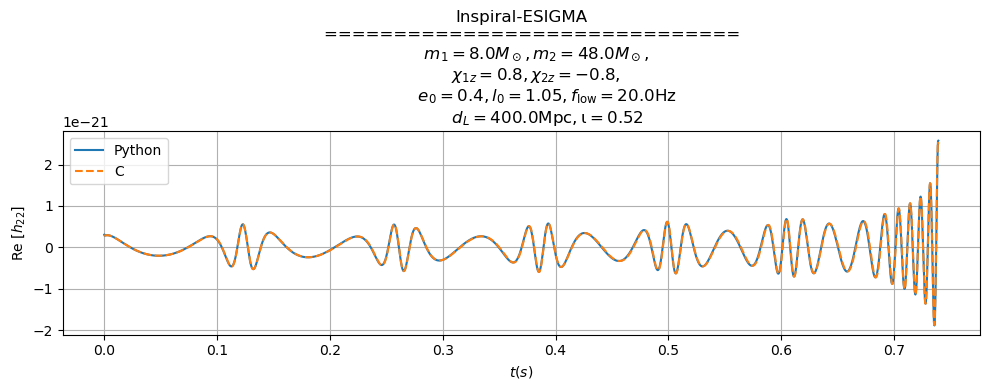

In [36]:
hp22_py_real_inspiral = inspiral_modes_py[(2, 2)].real()
hp22_c_real_inspiral = inspiral_modes_c[(2, 2)].real()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""Inspiral-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot$, 
      $\chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$, 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

hp22_py_real_inspiral.start_time=0
hp22_c_real_inspiral.start_time=0

plt.plot(hp22_py_real_inspiral.sample_times,hp22_py_real_inspiral,label='Python')
plt.plot(hp22_c_real_inspiral.sample_times,hp22_c_real_inspiral,label='C',ls='--')

plt.xlabel(r"$t (s)$")
plt.ylabel(r"Re [$h_{22}$]")
plt.legend()
plt.grid()
# plt.xlim(0.7,0.74)
# plt.ylim(-1e-21,1e-21)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(10, 4))
# plt.plot(hp22_py_real_inspiral.sample_times,hp22_py_real_inspiral,label='Python')
# plt.plot(hp22_c_real_inspiral.sample_times,hp22_c_real_inspiral,label='C',ls='--')

# plt.xlabel(r"$t (s)$")
# plt.ylabel(r"Re [$h_{22}$]")
# plt.legend()
# plt.grid()
# # plt.xlim(left=1.2, right=1.245)
# # plt.ylim(-1e-21,1e-21)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(10, 4))
# plt.semilogy(hp22_py_real_inspiral.sample_times,np.abs(hp22_py_real_inspiral-hp22_c_real_inspiral)/np.abs(hp22_c_real_inspiral),label='Python')

# plt.xlabel(r"$t (s)$")
# plt.ylabel(r"Re [$h_{22}$]")
# plt.legend()
# plt.grid()
# # plt.xlim(8.05,9.25)
# # plt.ylim(-1e-21,1e-21)
# plt.tight_layout()
# plt.show()

In [20]:
hp22_py_real_inspiral = inspiral_modes_py[(2, 2)].real()
hp22_c_real_inspiral = inspiral_modes_c[(2, 2)].real()
hp22_py_real_inspiral.start_time=0
hp22_c_real_inspiral.start_time=0
plt.figure(figsize=(10, 4))
plt.semilogy(hp22_py_real_inspiral.sample_times,np.abs(hp22_py_real_inspiral-hp22_c_real_inspiral),label='Python')

plt.xlabel(r"$t (s)$")
plt.ylabel(r"Re [$h_{22}$]")
plt.legend()
plt.grid()
# plt.xlim(1.05,1.25)
# plt.ylim(-1e-21,1e-21)
plt.tight_layout()
plt.show()

ValueError: lengths do not match (4652 vs 4653)

<Figure size 1000x400 with 0 Axes>

dict_keys([(2, 2), (2, -2)])


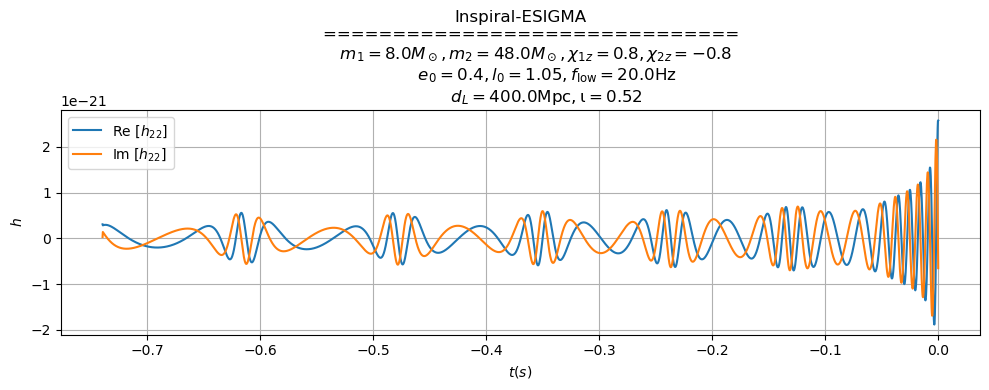

In [31]:
print(inspiral_modes_py.keys())
hp22_inspiral = inspiral_modes_py[(2, 2)].real()
hc22_inspiral = inspiral_modes_py[(2, 2)].imag()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""Inspiral-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

plt.plot(hp22_inspiral.sample_times,hp22_inspiral,label=r"Re [$h_{22}$]")
plt.plot(hc22_inspiral.sample_times,hc22_inspiral,label=r"Im [$h_{22}$]")

plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.grid()
plt.tight_layout()

### IMR ESIGMA modes

In [32]:
from esigmapy.python_codes import generator_python as gp

# m1 = 20.0  # masses (in solar masses)
# m2 = 30.0
# spin1z = 0.5  # dimensionless spins
# spin2z = -0.3
# eccentricity = 0.15  # starting eccentricity
# mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
# modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

# distance = 400.0  # source luminosity distance (in Mpc)
# inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

# f_low = 20.0  # starting frequency (in Hz)
# delta_t = 1 / 2**12  # time grid-spacing (in s)

print('================ Python ================')
imr_modes_py = gp.get_imr_esigma_modes_py(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)

print('================= C =================')
imr_modes_c = esigmapy.get_imr_esigma_modes(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)


================ Python ================
time taken = 0.8143424987792969 secs
3113 False
Orbital evolution took: 1.0490614450027351 seconds
Modes generation took: 0.4306351409977651 seconds
0.4. The orbital eccentricity at the end of inspiral was
0.038731628947603076. The merger-ringdown attachment with a quasicircular
model might be affected.
Generating MR waveform from 27.66742430543558Hz...
Hybridizing the following modes: [(2, 2), (2, -2)]
By aligning (2, 2) mode
..and inheriting the phase/time shifts for alignment of [(2, -2), (2, 2)] modes
INSPIRAL mode (2, 2) goes from -234.69690036721462Hz to 161.82422506567798Hz
MERGER mode (2, 2) goes from -799.1291300472742Hz to 1128.8976373558457Hz
INSPIRAL mode (2, -2) goes from -161.82422506567798Hz to 234.69690036721462Hz
MERGER mode (2, -2) goes from -1049.0987227068747Hz to 781.0501686609422Hz
blended.
================= C =================
Orbital evolution took: 0.015542758999799844 seconds
Modes generation took: 0.04799114799970994 s

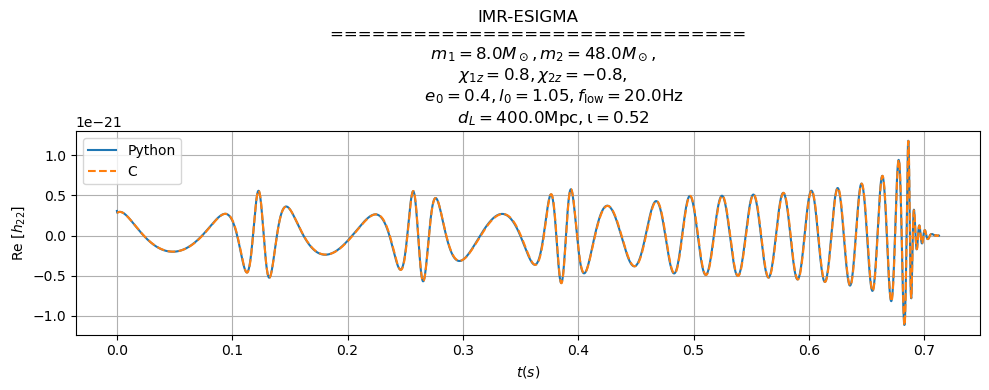

In [33]:
hp22_py_real_imr = imr_modes_py[(2, 2)].real()
hp22_c_real_imr = imr_modes_c[(2, 2)].real()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""IMR-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot$, 
      $\chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$, 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

hp22_py_real_imr.start_time=0
hp22_c_real_imr.start_time=0

plt.plot(hp22_py_real_imr.sample_times,hp22_py_real_imr,label='Python')
plt.plot(hp22_c_real_imr.sample_times,hp22_c_real_imr,label='C',ls='--')

plt.xlabel(r"$t (s)$")
plt.ylabel(r"Re [$h_{22}$]")
plt.legend()
plt.grid()
plt.tight_layout()

dict_keys([(2, 2), (2, -2)])


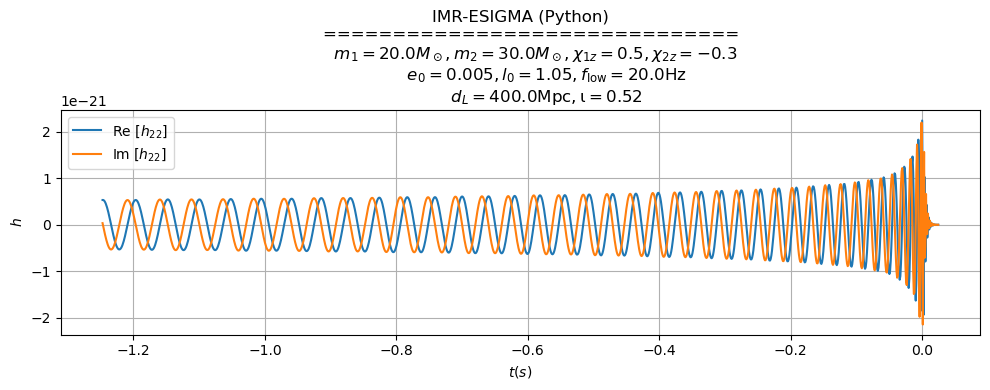

In [9]:
print(imr_modes_py.keys())
hp22_imr = imr_modes_py[(2, 2)].real()
hc22_imr = imr_modes_py[(2, 2)].imag()
plt.figure(figsize=(10, 4))
plt.title(
    rf"""IMR-ESIGMA (Python)
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

plt.plot(hp22_imr.sample_times,hp22_imr,label=r"Re [$h_{22}$]")
plt.plot(hc22_imr.sample_times,hc22_imr,label=r"Im [$h_{22}$]")

plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.grid()
plt.tight_layout()

## Checking evolution of dynamical quantities

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import lalsimulation as lalsim
from esigmapy.python_codes import esigma_pn_main as espn
import lal

/home/samanwaya/lalsuite-esigma-install/lib/python3.11/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


No version information file '.version' found


In [6]:
import os

os.environ["RadiationPNOrder"] = '8'
os.environ["ModePNOrder"] = '4'

x=os.environ.get("RadiationPNOrder")
y=os.environ.get("ModePNOrder")

print('radiation PN order is ' + ('not set' if x is None else str(int(x))))
print('mode PN order is ' + ('not set' if y is None else str(int(y))))

y=os.environ.get("LAL_DATA_PATH")
print('Poof!' if y is None else y)

radiation PN order is 8
mode PN order is 4
:/home/samanwaya/nrsur7dq4


### LALSuite (C) and python

In [7]:
m1 = 20.0  # masses (in solar masses)
m2 = 30.0
spin1z = 0.5  # dimensionless spins
spin2z = -0.5
eccentricity = 0.1  # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

f_low = 20.0  # starting frequency (in Hz)
delta_t = 1 / 4096.  # time grid-spacing (in s)

In [8]:
out_c = lalsim.SimInspiralESIGMADynamics(m1,m2,spin1z,spin2z,eccentricity,f_low,mean_anomaly,1e-12,1/delta_t)

time_c = out_c[0].data.data
x_c = out_c[1].data.data
e_c = out_c[2].data.data
meanan_c = out_c[3].data.data
phi_c = out_c[4].data.data
phidot_c = out_c[5].data.data
r_c = out_c[6].data.data
rdot_c = out_c[7].data.data

out_py = espn.inspiral_esigma_dynamics(m1,m2,spin1z,spin2z,eccentricity,f_low,mean_anomaly,1e-12,1/delta_t,)
print(out_py.keys())
time_py = out_py['time_evol']/(m1+m2)/lal.MTSUN_SI
x_py = out_py['x_evol']
e_py = out_py['eccentricity_evol']
meanan_py = out_py['mean_ano_evol']
phi_py = out_py['phi_evol']
phidot_py = out_py['phi_dot_evol']
r_py = out_py['r_evol']
rdot_py = out_py['r_dot_evol']

time taken = 2.5000295639038086 secs
4783 False
dict_keys(['time_evol', 'x_evol', 'eccentricity_evol', 'mean_ano_evol', 'phi_evol', 'phi_dot_evol', 'r_evol', 'r_dot_evol'])


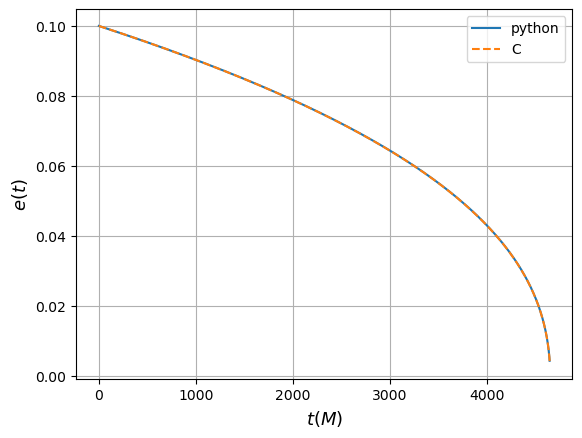

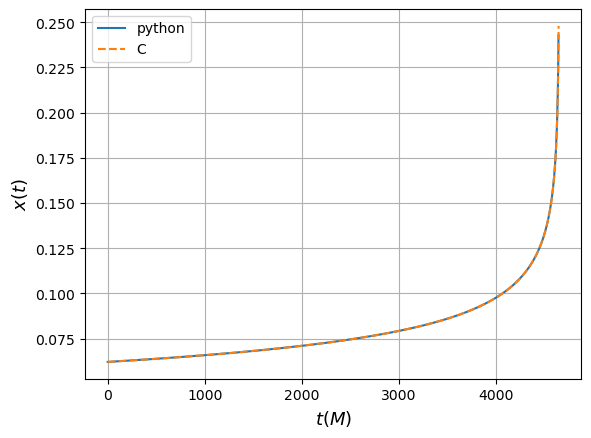

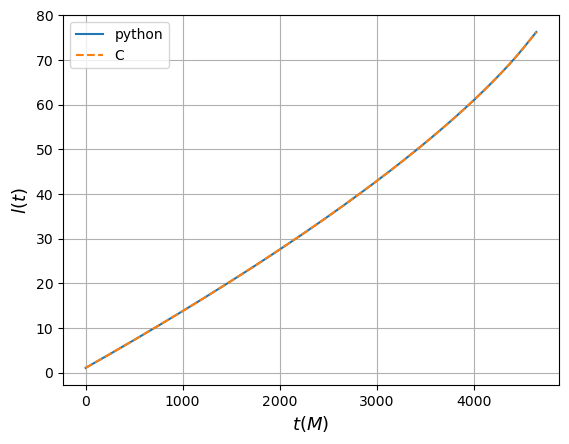

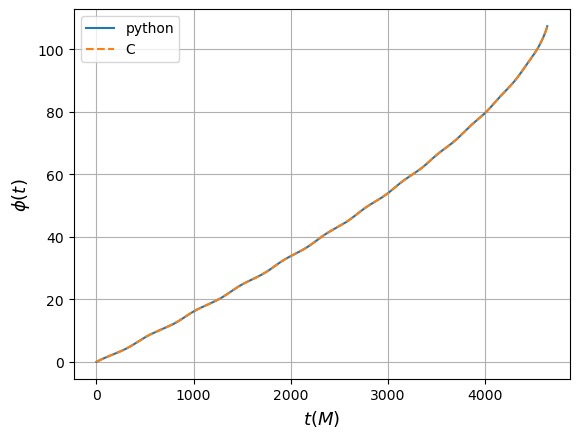

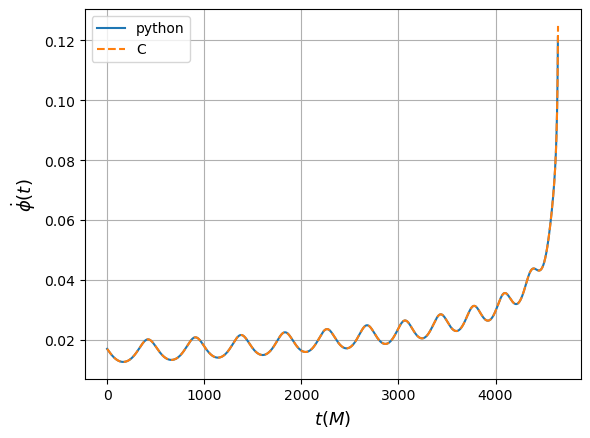

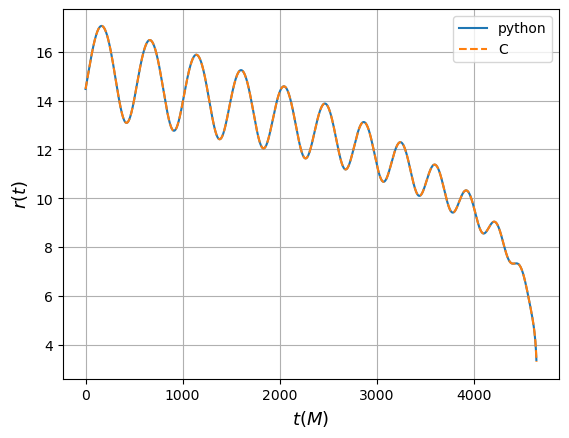

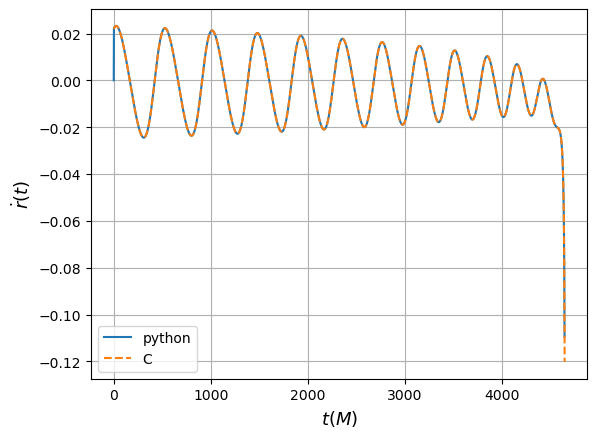

In [9]:
plt.plot(time_py,e_py,label='python')
plt.plot(time_c,e_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$e (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,x_py,label='python')
plt.plot(time_c,x_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$x (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,meanan_py,label='python')
plt.plot(time_c,meanan_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$l (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,phi_py,label='python')
plt.plot(time_c,phi_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$\\phi (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,phidot_py,label='python')
plt.plot(time_c,phidot_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$\\dot{\\phi} (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,r_py,label='python')
plt.plot(time_c,r_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$r (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

plt.plot(time_py,rdot_py,label='python')
plt.plot(time_c,rdot_c,ls='--',label='C')
plt.xlabel('$t (M)$',fontsize=13)
plt.ylabel('$\\dot{r} (t)$',fontsize=13)
plt.legend(), plt.grid()
plt.show()

## Check with SEOBNRv5EHM

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import esigmapy
from pyseobnr.generate_waveform import GenerateWaveform, generate_modes_opt
import lal
from esigmapy.python_codes import generator_python as gp


/home/samanwaya/esigmapy-dev/esigmapy/esigmapy/generator.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


No version information file '.version' found


In [3]:
m1 = 20.0  # masses (in solar masses)
m2 = 30.0
spin1z = 0.5  # dimensionless spins
spin2z = -0.3
eccentricity = 0.05 # starting eccentricity
mean_anomaly = 60 * np.pi / 180.0  # starting mean anomaly
modes_to_use = [(2, 2), (2, -2)]  # Only using the (2,2) mode

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

f_low = 50.0  # starting frequency (in Hz)
delta_t = 1 / 2048.  # time grid-spacing (in s)

# Input parameters for SEOB
q = m2/m1
chi_1, chi_2 = spin1z, spin2z
omega_start = np.pi*f_low*lal.MTSUN_SI #0.0137  # This is the orbital frequency in geometric units with M=1
# eccentricity = 0.4
rel_anomaly = mean_anomaly #2.3
print(omega_start)

0.0007736943088216417


In [4]:
print('================ Python ================')
imr_modes_py = gp.get_imr_esigma_modes_py(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)

print('================= C =================')
imr_modes_c = esigmapy.get_imr_esigma_modes(
    mass1=m1,
    mass2=m2,
    spin1z=spin1z,
    spin2z=spin2z,
    eccentricity=eccentricity,
    mean_anomaly=mean_anomaly,
    distance=distance,
    # inclination=inclination,
    f_lower=f_low,
    delta_t=delta_t,
    modes_to_use=modes_to_use,
    verbose=True
)

================ Python ================
Orbital evolution took: 0.6134227930015186 seconds
Modes generation took: 0.05245385800662916 seconds
Generating MR waveform from 50.11548092913955Hz...
Hybridizing the following modes: [(2, 2), (2, -2)]
By aligning (2, 2) mode
..and inheriting the phase/time shifts for alignment of [(2, -2), (2, 2)] modes
INSPIRAL mode (2, 2) goes from 47.79145657063043Hz to 122.77938006168975Hz
MERGER mode (2, 2) goes from 50.149759320137925Hz to 349.405367681844Hz
INSPIRAL mode (2, -2) goes from -122.77938006168975Hz to -47.79145657063043Hz
MERGER mode (2, -2) goes from -350.04376353886676Hz to -50.14885885724892Hz
blended.
================= C =================
Orbital evolution took: 0.003511044997139834 seconds
Modes generation took: 0.0018358320085098967 seconds
Generating MR waveform from 49.83655249209011Hz...
Hybridizing the following modes: [(2, 2), (2, -2)]
By aligning (2, 2) mode
..and inheriting the phase/time shifts for alignment of [(2, -2), (2, 2

In [ ]:
settings = dict(
    # "EccIC" determines the prescription for the starting frequency.
    # EccIC=0 means that omega_start corresponds to the *instantaneous* angular frequency, and
    # EccIC=1 means that omega_start corresponds to the *orbit-averaged* angular frequency [default option]
    EccIC=1,
    # Specify which modes are to be returned,
    return_modes=[(2, 2)],
)
# See the pyseobnr/generate_waveform.py file for a description of more settings


t_seob, modes_seob = generate_modes_opt(
    q,
    chi_1,
    chi_2,
    omega_start,
    eccentricity=eccentricity,
    rel_anomaly=rel_anomaly,
    approximant="SEOBNRv5EHM",
    settings=settings,
)


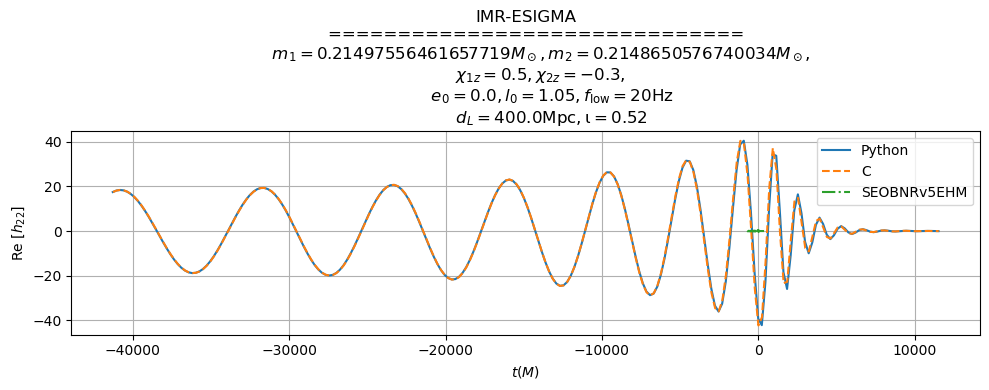

In [21]:
hp22_py_real_imr = imr_modes_py[(2, 2)].real()
hp22_c_real_imr = imr_modes_c[(2, 2)].real()
hp22_seob_imr = modes_seob['2,2'].real

plt.figure(figsize=(10, 4))
plt.title(
    rf"""IMR-ESIGMA
    ==============================
      $m_1={m1} M_\odot, m_2={m2} M_\odot$, 
      $\chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$, 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
# hp.plot(label=r"$h_+$")
# hc.plot(label=r"$h_\times$")

# hp22_py_real_imr.start_time=0
# hp22_c_real_imr.start_time=0

M = (m1+m2)*lal.MTSUN_SI
R = distance* 1e6 * lal.PC_SI / lal.C_SI

# plt.plot(hp22_py_real_imr.sample_times/M,hp22_py_real_imr*R/M,label='Python')
# plt.plot(hp22_c_real_imr.sample_times/M,hp22_c_real_imr*R/M,label='C',ls='--')
# plt.plot(t_seob,modes_seob['2,2'],label='SEOBNRv5EHM',ls='-.')

plt.plot(hp22_py_real_imr.sample_times/M,hp22_py_real_imr*R/M,label='Python')
plt.plot(hp22_c_real_imr.sample_times/M+12,hp22_c_real_imr*R/M,label='C',ls='--')
plt.plot(t_seob+8,hp22_seob_imr,label='SEOBNRv5EHM',ls='-.')

plt.xlabel(r"$t (M)$")
plt.ylabel(r"Re [$h_{22}$]")
plt.legend()
plt.grid()
# plt.xlim(left=-4000,right=-3000)
# plt.xlim(left=-100,right=100)
plt.tight_layout()

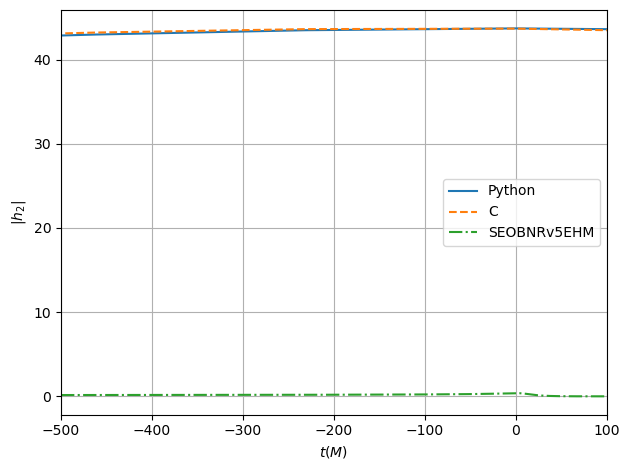

In [22]:
plt.plot(hp22_py_real_imr.sample_times/M,np.abs(imr_modes_py[(2, 2)]*R/M),label='Python')
plt.plot(hp22_c_real_imr.sample_times/M,np.abs(imr_modes_c[(2, 2)]*R/M),label='C',ls='--')
plt.plot(t_seob,np.abs(modes_seob['2,2']),label='SEOBNRv5EHM',ls='-.')

# plt.plot(hp22_py_real_imr.sample_times/M,hp22_py_real_imr*R/M,label='Python')
# plt.plot(hp22_c_real_imr.sample_times/M+12,hp22_c_real_imr*R/M,label='C',ls='--')
# plt.plot(t_seob+8,modes_seob['2,2'],label='SEOBNRv5EHM',ls='-.')

plt.xlabel(r"$t (M)$")
plt.ylabel(r"$|h_{2}|$")
plt.legend()
plt.grid()
# plt.xlim(left=-4000,right=-3000)
plt.xlim(left=-500,right=100)
plt.tight_layout()

In [20]:
from pycbc.waveform import get_td_waveform
from pycbc.filter import match
from pycbc.psd import aLIGOZeroDetHighPower
from pycbc.types import TimeSeries

TS_py = TimeSeries(hp22_py_real_imr,delta_t=delta_t)
TS_c = TimeSeries(hp22_c_real_imr,delta_t=delta_t)
TS_seob = TimeSeries(hp22_seob_imr,delta_t=delta_t)

f_low = 20
sample_rate = 2048

tlen = max(len(TS_seob), len(TS_c), len(TS_py))
TS_c.resize(tlen)
TS_py.resize(tlen)
TS_seob.resize(tlen)

# Generate the aLIGO ZDHP PSD
delta_f = 1.0 / TS_c.duration
flen = tlen//2 + 1
psd = aLIGOZeroDetHighPower(flen, delta_f, f_low)

# Note: This takes a while the first time as an FFT plan is generated
# subsequent calls are much faster.
m1, _ = match(TS_c, TS_seob, psd=psd, low_frequency_cutoff=f_low)
m2, _ = match(TS_py, TS_seob, psd=psd, low_frequency_cutoff=f_low)
print('The match with C is: {:.4f}'.format(m1))
print('The match with python is: {:.4f}'.format(m2))

The match with C is: 0.2150
The match with python is: 0.2149
